In [1]:
%cd ..

/home/fzimin/Projects/depth-poset


In [2]:
import numpy as np
import networkx as nx
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from src.depth import DepthPoset, ShallowPair
from src.transpositions import Transposition

from IPython.display import display, Markdown

import itertools

from src.equation import Equation
from equations import lemma33


from tqdm.auto import tqdm

import io
import base64

import os
import pickle as pkl
from src.hash import hash_boundary_matrix

from pathlib import Path
from markdown import markdown


/home/fzimin/Projects/depth-poset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load and Save Complex

In [3]:
def get_dims(ns):
    return np.concatenate([i*np.ones(n, dtype=int) for i, n in enumerate(ns)])

In [4]:
def get_betti_from_depth_poset(ns: list[int], dp: DepthPoset):
    """
    """
    bs = np.array(ns)
    for node in dp.nodes:
        dim = int(node.dim)
        bs[[dim, dim + 1]] -= 1
    return bs


In [5]:
def get_delta_data(delta, ns, betti=None, path='data/complexes/absract'):
    """
    """
    hash = hash_boundary_matrix(delta)
    filename = os.path.join(path, f'{hash}.pkl')
    try:
        with open(filename, 'rb') as file:
            data = pkl.load(file)
    except FileNotFoundError:
        dims = get_dims(ns)
        dp = DepthPoset.from_border_matrix(delta, dims)
        if betti is None:
            betti = get_betti_from_depth_poset(ns, dp)
        data = {
            'hash': hash, 
            'boundary_matrix': np.array(delta, dtype=bool), 
            'dims': dims, 
            'betti': betti,
            'depth_poset': dp, 
        }

        os.makedirs(path, exist_ok=True)
        with open(filename, 'wb') as file:
            pkl.dump(data, file)
    return data

In [6]:
def load_data(hash, path='data/complexes/absract'):
    """
    """
    filename = os.path.join(path, f'{hash}.pkl')
    with open(filename, 'rb') as file:
        data = pkl.load(file)
    return data

# Visualization Tools

## Visualize the Boundary Matrix

In [7]:
def show_boundary_matrix(delta_matrix, ns, ax=None, cmap='Blues', 
                         grid_linewidth=2, grid_alpha=1.0, grid_color='black', set_lim=True):
    if ax is None:
        ax = plt.gca()

    assert len(delta_matrix) == np.sum(ns)

    ax.imshow(delta_matrix, cmap)

    grid_ticks = np.cumsum(np.append(0, ns)) - 0.5
    
    ax.set_xticks(np.arange(len(delta_matrix)))
    ax.set_xticklabels(np.arange(len(delta_matrix)))
    ax.set_xticks(grid_ticks, minor=True)
    ax.set_yticks(np.arange(len(delta_matrix)))
    ax.set_yticklabels(np.arange(len(delta_matrix)))
    ax.set_yticks(grid_ticks, minor=True)

    if set_lim:
        ax.set_xlim(grid_ticks[1], grid_ticks[-1])
        ax.set_ylim(grid_ticks[-2], grid_ticks[0])

    ax.grid(which="minor", linewidth=grid_linewidth, alpha=grid_alpha, color=grid_color)
    

## Visualize the Depth Poset under the Transposition

In [8]:
def plot_depth_poset_under_the_transposition(dp: DepthPoset, a: int | None=None, b: int | None=None, x: int | None=None, y: int | None=None, 
                                        ax=None, common_color='lightgrey', transposition_color='gold', node_size=1200):
    if ax is None:
        ax = plt.gca()

    abxy = {a, b, x, y}
    colorfull_sources = set(itertools.product(abxy, abxy))

    pos = dp.hasse_layout()
    node_colors = [common_color if (node.source is None) or (len(set(node.source) & abxy) == 0) else transposition_color for node in dp.nodes]
    #node_colors = [common_color if node.source in colorfull_sources else transposition_color for node in dp.nodes]
    
    nx.draw_networkx(dp.get_transitive_reduction(), pos, node_color=node_colors, node_size=node_size, ax=ax)

In [9]:
def plot_transposition_triplet(delta_matrix, ns, dp_bt, dp_at, a, b, x, y, transposition_type, figsize=(15, 5), 
                               cmap='Blues', marker_value=0.3, grid_linewidth=2, grid_alpha=1.0, grid_color='black', set_lim=True, 
                               common_color='lightgrey', transposition_color='gold', node_size=1200, **kwargs):
    fig, axs = plt.subplots(1, 3, figsize=figsize)
    
    transp_cells = {'birth-birth': [a, x], 
                    'death-death': [b, y], 
                    'birth-death': [b, x]}[transposition_type]
    
    delta_show = np.array(delta_matrix).astype(float)
    delta_show[transp_cells, :] += marker_value
    delta_show[:, transp_cells] += marker_value

    show_boundary_matrix(delta_show, ns, ax=axs[0], cmap=cmap, grid_linewidth=grid_linewidth, grid_alpha=grid_alpha, grid_color=grid_color, set_lim=set_lim)
    
    plot_depth_poset_under_the_transposition(dp_bt, a, b, x, y, ax=axs[1], common_color=common_color, transposition_color=transposition_color, node_size=node_size)
    plot_depth_poset_under_the_transposition(dp_at, a, b, x, y, ax=axs[2], common_color=common_color, transposition_color=transposition_color, node_size=node_size)

    axs[0].set_title(r'$\text{Boundary Matrix}^\text{bt}$')
    axs[1].set_title(r'$\text{Depth Poset}^\text{bt}$')
    axs[2].set_title(r'$\text{Depth Poset}^\text{at}$')

    return fig, axs
        

    

## Markdown Tables

### One Transposition

In [10]:
def latex_tuple_sets(s: set):
    if len(s) == 0:
        return r'$\emptyset$'
    else:
        str_s = {(int(a), int(b)) for a, b, in s}
        str_s = f'${str_s}$'
        str_s = str_s.replace('{', r'\{').replace('}', r'\}')
        return str_s

In [11]:
def unite(idx, col, val):
    idx = idx.replace('$', '')
    col = col.replace('$', '')
    val = val.replace('$', '')
    return f"${col.replace(r'\text{Set}', idx)} = {val}$"

In [12]:
def get_nodes_table(dp_bt, dp_at):
    """
    """
    df = pd.DataFrame([[latex_tuple_sets([node.source for node in dp_bt.nodes])], 
                       [latex_tuple_sets([node.source for node in dp_at.nodes])]], 
                       index=['Before the transposition', 'After the transposition'], columns=[''])

    return df

In [13]:
def relation_index_to_source(dp: DepthPoset, relations: list[tuple]):
    return [tuple(np.array(dp._sources)[list(relation)]) for relation in relations]

In [14]:
def get_relations_table(dp_bt, dp_at):
    """
    """
    df = pd.DataFrame([[latex_tuple_sets(relation_index_to_source(dp_bt, dp_bt._b0_set)), latex_tuple_sets(relation_index_to_source(dp_bt, dp_bt._b1_set))], 
                       [latex_tuple_sets(relation_index_to_source(dp_at, dp_at._b0_set)), latex_tuple_sets(relation_index_to_source(dp_at, dp_at._b1_set))]], 
                       index=['Before the transposition', 'After the transposition'], columns=['Algorithm 1', 'Algorithm 2'])
    return df


In [15]:
def get_succ_pred_table(dp_bt, dp_at, a, b, x, y, transposition_type='birth-birth', **kwargs):
    set_funs = [lemma33.get_pred1, lemma33.get_pred2, lemma33.get_succ1, lemma33.get_succ2]
    
    if transposition_type == 'birth-birth':
        set_args = [(dp_bt, a, b), (dp_bt, x, y), (dp_at, a, y), (dp_at, x, b), ]
    if transposition_type == 'death-death':
        set_args = [(dp_bt, a, b), (dp_bt, x, y), (dp_at, x, b), (dp_at, a, y), ]
    if transposition_type == 'birth-death':
        set_args = [(dp_bt, a, b), (dp_bt, x, y), (dp_at, a, x), (dp_at, b, y), ]
    

    arg_index = np.repeat([r'$\text{{Set}}^\text{{bt}}({a}, {b})$', 
                           r'$\text{{Set}}^\text{{at}}({a}, {b})$'], 2)
    arg_index = [s.format(a=a, b=b) for s, (dp, a, b) in zip(arg_index, set_args)]


    df = pd.DataFrame({f'$\\text{{{f.__name__[4:-1].capitalize()}}}_{f.__name__[-1]}$': [f(*args) for args in set_args] for f in set_funs}, index=arg_index)
    df = df.map(latex_tuple_sets)
    df = df.transpose()

    for idx in df.index:
        for col in df.columns:
            df.loc[idx, col] = unite(idx, col, df.loc[idx, col])

    df = df.iloc[[2, 0, 3, 1]]
    return df

In [16]:
def get_set_funs_table(dp_bt, dp_at, a, b, x, y, transposition_type=None, set_funs=None):
    """
    """
    if set_funs is None:
        if transposition_type == 'birth-birth':
            set_funs = [lemma33.get_l_set, lemma33.get_m_set]
        elif transposition_type == 'death-death':
            set_funs = [lemma33.get_b_set, lemma33.get_n_set]
        else:
            set_funs = [lemma33.get_a1_set, lemma33.get_b1_set, lemma33.get_a2_set, lemma33.get_b2_set]

    dps_dict = {'Before the Transposition': dp_bt, 'After the Transposition': dp_at}
    df = pd.DataFrame({key: [f(item, a, b, x, y) for f in set_funs] for key, item in dps_dict.items()}, 
                      index=[f.__doc__.strip() for f in set_funs])
    df = df.map(latex_tuple_sets)
    return df

In [17]:
def add_params(s, open_chars='([', close_chars='])', **kwargs):
    """
    """
    res = str(s)
    for key, item in kwargs.items():
        for c in open_chars:
            res = res.replace(f'{c}{key}', f'{c}{item}')
        for c in close_chars:
            res = res.replace(f'{key}{c}', f'{item}{c}')
    return res


In [18]:
def get_equations_table(equations: list[Equation], use_correct_symbols: bool=True, **kwargs):
    """
    """
    df = pd.DataFrame([{'eq': eq.__class__.__name__, 
                        'left (formula)': f'${eq.left_str}$', 
                        'left (paramatrized)': f'${add_params(eq.left_str, **kwargs)}$', 
                        'left (value)': eq.left(**kwargs), 
                        'right (formula)': f'${eq.right_str}$', 
                        'right (paramatrized)': f'${add_params(eq.right_str, **kwargs)}$',
                        'right (value)': eq.right(**kwargs), 
                        'correct': eq.is_correct(**kwargs),
                        } for eq in equations])
    if not df.empty:
        df = df.set_index('eq')

        for col in ['left (value)', 'right (value)']:
            df[col] = df[col].apply(latex_tuple_sets)
    if use_correct_symbols:
        df['correct'] = df['correct'].replace({False: '✘', True: '✔'})

    return df

In [19]:
def get_transposition_stats(cell0, cell1, dp_bt, dp_at, transposition_type, switch_type, x, y, a, b, transposition, 
                            checked_equations, show_all_equations: bool=True, 
                            delta=None, hash_bt=None, imagewidth=1000, path='data/complexes/absract', 
                            header_level=1, subheader_level=None, complex_name=None, **kwargs):
    """
    """
    if subheader_level is None:
        subheader_level = header_level + 1

    header = '#'*header_level
    subheader = '#'*subheader_level

    wrong_equations_count = (checked_equations == False).sum()
    if show_all_equations:
        equations_names = checked_equations[~pd.isna(checked_equations)].index
    else: 
        equations_names = checked_equations[checked_equations == False].index
    equations = [getattr(lemma33, eq)() for eq in equations_names]
    equations_table = get_equations_table(equations, dp_bt=dp_bt, dp_at=dp_at, x=x, y=y, a=a, b=b, transposition=transposition)

    if (delta is None) and (hash_bt is None):
        insert_image_str = ""
    else:
        if (delta is None):
            delta = load_data(hash_bt, path)['boundary_matrix']
        fig, axs = plot_transposition_triplet(delta, ns, dp_bt, dp_at, a, b, x, y, transposition_type)
        buffer = io.BytesIO()
        fig.savefig(buffer, format="png", bbox_inches="tight")
        plt.close()
        buffer.seek(0)
        image = base64.b64encode(buffer.getvalue()).decode("utf-8")
        insert_image_str = f"""<img src="data:image/png;base64,{image}" width="{imagewidth}">"""

    if complex_name is None:
        comlex_name_str = ''
    else:
        comlex_name_str = f'in complex {complex_name}'


    try:
        succ_pred_table = get_succ_pred_table(dp_bt, dp_at, a, b, x, y, transposition_type).to_markdown()
    except Exception as err:
        succ_pred_table = str(err)
    try:
        set_funs_table = get_set_funs_table(dp_bt, dp_at, a, b, x, y, transposition_type, set_funs=None).to_markdown()
    except Exception as err:
        set_funs_table = str(err)


    
    text = f"""
    {header} Transposition <{cell0}, {cell1}> {comlex_name_str}
    Here is a __{transposition_type}__ __{switch_type}__ transposition <{cell0}, {cell1}>.
    
    $$
        a = {a}, \\; b = {b}, \\; x = {x}, \\; y = {y}
    $$
    
    {insert_image_str}
    
    {subheader} Birth Death Pairs
    {get_nodes_table(dp_bt, dp_at).to_markdown()}

    {subheader} Relations
    {get_relations_table(dp_bt, dp_at).to_markdown()}

    {subheader} Successors and Predecessers
    {succ_pred_table}

    {subheader} Temp Sets
    {set_funs_table}

    {subheader} Equations
    There are {wrong_equations_count} equations are wrong{'.' if (wrong_equations_count == 0) or show_all_equations else ':'}

    {equations_table.to_markdown()}
    
    """
    text = text.strip().replace('\n    ', '\n')

    return text

### Transpositions in Complex

In [20]:
def get_complex_stats(boundary_matrix, depth_poset: DepthPoset, dims, betti, imagewidth=1000, hash=None):
    """
    """
    dim = int(np.max(dims))
    ns = pd.Series(dims).astype(int).value_counts().sort_index().values
    n_cells = np.sum(ns)
    assert n_cells == len(boundary_matrix) 

    df_cells_betti = pd.DataFrame({'Dimension': np.arange(dim + 1), 'Number of Cells': ns, 'Betti Number': betti}).set_index('Dimension')

    if np.all([node.source is None for node in depth_poset.nodes]):
        depth_poset.update_sources(np.arange(n_cells))

    # plot Boundary Matrix and the Depth Poset
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].set_title('Boundary Matrix')
    show_boundary_matrix(boundary_matrix, ns, ax=axs[0])
    axs[1].set_title('Depth Poset')
    plot_depth_poset_under_the_transposition(depth_poset, ax=axs[1])
    buffer = io.BytesIO()
    plt.savefig(buffer, format="png", bbox_inches="tight")
    plt.close()
    buffer.seek(0)
    image = base64.b64encode(buffer.getvalue()).decode("utf-8")
    image_str = f"""<img src="data:image/png;base64,{image}" width="{imagewidth}">"""

    text = f"""
    The complex dimendion {dim} with {n_cells} cells:
    
    {df_cells_betti.to_markdown()}

    Its Depth Poset has {len(depth_poset.nodes)} nodes.

    {image_str}
    """
    text = text.strip().replace('\n    ', '\n')

    return text

In [21]:
def get_complex_stats_stats_dict(boundary_matrix, depth_poset: DepthPoset, dims, betti, hash=None):
    """
    """
    dim = int(np.max(dims))
    ns = pd.Series(dims).astype(int).value_counts().sort_index().values
    n_cells = np.sum(ns)
    assert n_cells == len(boundary_matrix) 

    return {
        'hash': hash, 
        'dim': dim, 
        'n_cells': n_cells, 
        'ns': np.asarray(ns, dtype=int), 
        'betti': np.asarray(betti, dtype=int), 
        'dp_nodes': len(depth_poset.nodes), 
    }


In [22]:
def to_latex_vector(arr):
    return '$(' + ', '.join(np.array(arr).astype(str)) + ')$'

In [23]:
def get_complexes_distribution(hashes, path='data/complexes/abstract'):
    """
    """
    df = []
    for hash in hashes:
        df.append(get_complex_stats_stats_dict(**load_data(hash, path)))
    df = pd.DataFrame(df)

    df['ns'] = df['ns'].apply(to_latex_vector)
    df['betti'] = df['betti'].apply(to_latex_vector)
    

    df = df.groupby(['dim', 'n_cells', 'ns', 'betti', 'dp_nodes'])['hash'].count().reset_index()
    df.columns = ['Dimension', 'Cells', '$n$-vector', 'Betti-vector', 'Nodes in Depth Poset', 'Complexes']
    return df

In [24]:
hashes = ['amFTMHIVFMOJB9MtV6DsTajMdFwgqn5H0HNwXN_sdXI', 
          'cbMF7G-eF8NIrEadRbHkeslxobJ68Yi70RuiDulhA1U', 
          'kdg5GU7fqXPXOdbLvKsMhkVXqxtYmXvOHNwHOtvOqMs', 
          'GCj6OFl1GpxfzNR37bdY-uOSDI41MY5OPUOVDkrBQjg',
          '_DJQ7xi5uboepf2K8nN3lVQfLIlrT-Ds0nuY_AbWghc',
          'Xd7PNFbYd-UwLgATpOpyxqNDFxt4S_dhP3qe2qAUAzM',
          '8PoU1xUuf6RFh5YEutXLHMQqH9XFLoKT0I1erPo2GTE',
          '6EXRO1r6RZQ-vmgKrFEHRHF3izWLfv-YBH35lk78Vjg',
          'V-41pOKSDqvFvx8b86-k7ATVWxuHXVuHefTJ_jw6XH0',
          '9vKVxhWKG_jA95aUja31nYKIcC_1IgxMUl46u1pZlXI',
          'OItJ6mSszTLuaqrBhvhMKMXKdNxDasMfnhnPih-56u0',
          'IgFXyFYucU-cuXjeTeSPG_zhbYJFoP1-ZYpLtXSMaUU',
          'eZOt5oQQe2x9zVQVqFT0yaCmtEO3Epew7sjrp6OzT2k',
          'shvCWEOALZr8YCq_9tJMTNaW5f3kmOO_YmmJ0ZxWlzA',
          'VmxRTo1ZiTgmmAX5CRwHPvj46EqAO8_YE4WW5Visbjg',
          'fb75AFybTPtHGWSomZGslzKSRzvve1_ANljaSBDmWVg',
          'WrgsyDaXXvK8GyOhAztCSv5vja0FhTdSNqkXA3hxbd4',
          'GZq7av0SS3fEfzBSSzNLVV9sAQ9-icuv4PJd8xzMyvc',
          'L_tyb2KrHrlVMa255RSsKzC9Z2sqhIgDPnmbLbhjcU8',
          'y0P-VLGs5R8Obom06r2PvGIhdskQ1fVdTiuTiBIvsz4',
          '8PfQ9REj2dqlrYbeXk8uypwYcdOvvTw4os16-F3WYEA',
          '5s9FyvPrP6pf4IEK_iL9N9xZCl8e9RbgTXBWBQEyZx8',
          'elr7D3gMUOrLeuLqbQpfhZn18R-3LjfNp4HNnlptJks',
          'B4uUx6D9CzoiTsU9E4jJOZJGEuE3Zb7-OUeeEPGyV8U',
          'CfGDvub6JvHrIxcq7bJjCHNVOv2z6Yx6KDmgvt2CZDo']

get_complexes_distribution(hashes)

,Dimension,Cells,$n$-vector,Betti-vector,Nodes in Depth Poset,Complexes
0,3,48,"$(6, 15, 18, 9)$","$(1, 0, 0, 1)$",23,5
1,3,48,"$(6, 15, 18, 9)$","$(1, 0, 1, 2)$",22,5
2,3,48,"$(6, 15, 18, 9)$","$(1, 1, 1, 1)$",22,5
3,3,48,"$(6, 15, 18, 9)$","$(1, 1, 2, 2)$",21,5
4,3,48,"$(6, 15, 18, 9)$","$(1, 2, 2, 1)$",21,5


In [25]:
pass

In [26]:
def glue_switch_type_and_nested(df_transpositions: pd.DataFrame) -> pd.DataFrame:
    """
    """
    df_res = df_transpositions.copy()
    if 'nested' in df_transpositions.columns:
        df_res['switch_type'] = df_res.apply(lambda row: row['switch_type'] + ('' if row['switch_type'] != 'no switch' else f' ({'' if row["nested"]else 'not '}nested)'), axis=1)
        df_res = df_res.drop(columns='nested')
    return df_res
    

In [27]:
def get_transpositions_distrubution_table(df_transpositions):
    """
    """
    df_res = glue_switch_type_and_nested(df_transpositions)[['transposition_type', 'switch_type']].value_counts().reset_index()
    df_res = df_res.pivot_table(index='transposition_type', columns='switch_type', values='count').fillna(0).astype(int)

    return df_res

In [28]:
def get_transposition_equations_correctness_distribution_table_tall(df_transpositions, eq_cols=None, 
                                                                    percent_representation: bool=True):
    """
    """
    df_transpositions = glue_switch_type_and_nested(df_transpositions)
    if eq_cols is None:
        eq_cols = df_transpositions.columns.values
        eq_cols = eq_cols[list(map(lambda s: s.find('Eq') == 0, eq_cols))]

    df_res = df_transpositions.groupby(['transposition_type', 'switch_type'])[eq_cols].mean().reset_index()
    df_res = df_res.melt(id_vars=['transposition_type', 'switch_type'], var_name='Name', value_name='Correct')
    df_res = df_res[~pd.isna(df_res['Correct'])]

    if percent_representation:
        df_res['Correct'] = df_res['Correct'].apply(lambda val: f'{val*100:.0f}%')


    df_res['Formula'] = df_res['Name'].apply(lambda eq_name: str(getattr(lemma33, eq_name)()))

    df_res = df_res[['Name', 'Formula', 'transposition_type', 'switch_type', 'Correct']]
    df_res = df_res.sort_values(['Name', 'transposition_type'])
    df_res.columns = ['Name', 'Formula', 'Transposition Type', 'Switch Type', 'Correct']
    
    return df_res

In [29]:
def get_transpositions_stats(df_transpositions, path='data/complexes/absract', show_all_equations=True, eq_cols=None, 
                             imagewidth=1000, max_complexes_to_show=5, intro_text=None, unique_eq_vectors=bool):
    """
    """
    # complexes in data
    hashes_bt = list(pd.unique(df_transpositions['hash_bt']))

    if intro_text is None:
        text = ''
    else:
        text = f'{intro_text}\n\n'

    text += f"""
    # Data 
    We have {len(hashes_bt)} complex{'es' if len(hashes_bt) != 1 else ''}.
    """
    
    if len(hashes_bt) <= max_complexes_to_show:
        for hash_i, hash in enumerate(hashes_bt):
            data = load_data(hash, path)
            text += f'\n## Complex {hash_i}\n'
            text += get_complex_stats(**data, imagewidth=imagewidth) + '\n'
    else:
        df_complex_stats = get_complexes_distribution(hashes_bt, path)
        text += f"\n{df_complex_stats.to_markdown()}\n"


    # transpositions
    df_transp_distr = get_transpositions_distrubution_table(df_transpositions)
    text += f"""
    # Transpositions
    In this data we got {len(df_transpositions)} by transposing consecutive pairs. The distribution of the transposition types is given in the table:
    
    {df_transp_distr.to_markdown()}

    """

    # equations
    if eq_cols is None:
        eq_cols = df_transpositions.columns.values
        eq_cols = eq_cols[list(map(lambda s: s.find('Eq') == 0, eq_cols))]
    
    df_eqs_stats_bb = get_transposition_equations_correctness_distribution_table_tall(df_transpositions[df_transpositions['transposition_type'] == 'birth-birth'], eq_cols=eq_cols)
    df_eqs_stats_dd = get_transposition_equations_correctness_distribution_table_tall(df_transpositions[df_transpositions['transposition_type'] == 'death-death'], eq_cols=eq_cols)
    df_eqs_stats_bd = get_transposition_equations_correctness_distribution_table_tall(df_transpositions[df_transpositions['transposition_type'] == 'birth-death'], eq_cols=eq_cols)

    text += f"""
    # Equations
    We checked {len(eq_cols)} equations. And we can see the distribution of transposiions, satysfying these equations in the tables:

    ## Birth-Birth Transpositions
    {df_eqs_stats_bb.to_markdown(index=False)}

    ## Death-Death Transpositions
    {df_eqs_stats_dd.to_markdown(index=False)}

    ## Birth-Death Transpositions
    {df_eqs_stats_bd.to_markdown(index=False)}
    """

    # Examples of incorrect 
    df_transpositions_wrong = df_transpositions[(df_transpositions[eq_cols] == False).any(axis=1)]
    num_transpositions_wrong = len(df_transpositions_wrong)
    if unique_eq_vectors:
        df_transpositions_wrong = df_transpositions_wrong[
            ~(df_transpositions_wrong[eq_cols] == False).duplicated()
        ]

    text += f"""
    # Incorrect Equations
    We have {num_transpositions_wrong} transpositions, such that some equations are incorrect.
    """
    if num_transpositions_wrong > 0:
        text += 'We will list some examples.\n\n'

    for i, row in tqdm(df_transpositions_wrong.iterrows(), total=len(df_transpositions_wrong), desc='Wrong Transpositions'):
        complex_name = hashes_bt.index(row['hash_bt'])
        text += get_transposition_stats(**row, checked_equations=row[eq_cols], header_level=2, path=path, show_all_equations=show_all_equations, imagewidth=imagewidth, complex_name=complex_name)
        text += '\n\n'
    
    text = text.strip().replace('\n    ', '\n')

    return text

# Collect Transpositions Data

## Associate Transposition with Equations

In [30]:
@np.vectorize
def get_equation_from_number(i):
    return getattr(lemma33, f'Eq{i:02d}')()

In [31]:
def associate_equations(transposition_type, switch_type, nested, with_preservation: bool=True):
    """
    """
    if transposition_type == 'birth-birth' and switch_type == 'switch forward':
        return get_equation_from_number(np.arange(8, 16))
    elif transposition_type == 'birth-birth' and switch_type == 'no switch' and nested:
        return get_equation_from_number(np.arange(16, 18))
    elif transposition_type == 'birth-birth' and switch_type == 'switch backward':
        return get_equation_from_number(np.arange(26, 28))
    
    elif transposition_type == 'death-death' and switch_type == 'switch forward':
        return get_equation_from_number(np.arange(28, 36))
    elif transposition_type == 'death-death' and switch_type == 'no switch' and nested:
        return get_equation_from_number(np.arange(36, 38))
    elif transposition_type == 'death-death' and switch_type == 'switch backward':
        return get_equation_from_number(np.arange(46, 48))

    elif transposition_type == 'birth-death' and switch_type == 'switch forward':
        #return get_equation_from_number(np.arange(48, 56))
        return np.concatenate([get_equation_from_number(np.arange(48, 56)), 
                               [lemma33.Eq50a(), lemma33.Eq50b(), lemma33.Eq55a(), lemma33.Eq55b()]])
                              
            
    elif switch_type == 'no switch' and with_preservation:
        return [lemma33.EqSucc1ab(), lemma33.EqSucc1xy(), lemma33.EqPred1ab(), lemma33.EqPred1xy(), 
                lemma33.EqSucc2ab(), lemma33.EqSucc2xy(), lemma33.EqPred2ab(), lemma33.EqPred2xy()]
    else:
        return []


In [32]:
@np.vectorize
def associate_case(eq_name):
    """
    """
    df_cases_equations = pd.DataFrame(
        [
            {
                'transposition_type': transposition_type, 
                'switch_type': switch_type, 
                'nested': switch_type, 
            } for transposition_type, switch_type, nested in itertools.product(
                ['birth-birth', 'death-death', 'birth-death'], 
                ['switch forward', 'switch backward', 'no switch'], 
                [True, False]
            )
        ]
    )
    df_cases_equations['equations'] = df_cases_equations.apply(lambda row: associate_equations(**row), axis=1)
    df_cases_equations['equations'] = df_cases_equations['equations'].apply(lambda arr: [eq.__class__.__name__ for eq in arr])

    res = df_cases_equations[df_cases_equations['equations'].apply(lambda arr: np.any(arr == eq_name))][['transposition_type', 'switch_type', 'nested']]
    return res

## Get Transpositions Tables

In [33]:
def collect_transpositions(delta, ns, betti=None, path='data/complexes/absract', filter_unpaired: bool=True):
    """
    """
    df_transpositions = []

    dims = get_dims(ns)

    assert len(delta) == np.sum(ns)
    n = len(delta)

    data_bt = get_delta_data(delta, ns, betti=betti, path=path)
    data_bt['depth_poset'].update_sources(np.arange(n))
    betti = data_bt['betti']

    
    for cell0, cell1 in itertools.pairwise(range(len(delta))):
        if (dims[cell0] != dims[cell1]) and filter_unpaired:
            continue
        reorder = np.arange(n)
        reorder[[cell0, cell1]] = reorder[[cell1, cell0]]

        delta_at = delta[reorder, :][:, reorder]
        data_at = get_delta_data(delta_at, ns, betti=betti, path=path)
        data_at['depth_poset'].update_sources(reorder)
        
        df_transpositions.append(
            {
                'cell0': cell0, 
                'cell1': cell1, 
                'hash_bt': data_bt['hash'], 
                'hash_at': data_at['hash'], 
                'dp_bt': data_bt['depth_poset'], 
                'dp_at': data_at['depth_poset'], 
            }
        )
    df_transpositions = pd.DataFrame(df_transpositions)

    df_transpositions['transposition'] = df_transpositions.apply(lambda row: Transposition(delta, row['cell0'], row['cell1'], dims=dims, order=np.arange(n), dp=row['dp_bt']), axis=1)

    df_transpositions['transposition_type'] = df_transpositions['transposition'].apply(lambda transp: transp.get_transposition_type())
    if filter_unpaired:
        df_transpositions = df_transpositions[df_transpositions['transposition_type'].isin(['birth-birth', 'death-death', 'birth-death'])]
    df_transpositions['switch_type'] = df_transpositions['transposition'].apply(lambda transp: transp.get_switch_type())
    df_transpositions['nested'] = df_transpositions['transposition'].apply(lambda transp: transp.is_nested())

    def get_xyab_from_row(row):
        if row['transposition_type'] not in ['birth-birth', 'death-death', 'birth-death']:
            return None, None, None, None
        return row['transposition'].get_xyab()
    df_transpositions['xyab'] = df_transpositions.apply(get_xyab_from_row, axis=1)
    for i, c in enumerate('xyab'):
        df_transpositions[c] = df_transpositions['xyab'].apply(lambda v: v[i]).astype('Int64')
    df_transpositions = df_transpositions.drop(columns='xyab')

    return df_transpositions
    

In [34]:
def applyer(func, return_error=True):
    def wrapped(*args, **kwargs):
        try:
            return func(*args, **kwargs)
        except Exception as err:
            if return_error:
                return err
            raise

    return wrapped


def apply_functions(df_inputs: pd.DataFrame, df_funcs: pd.DataFrame, return_error=True) -> pd.DataFrame:

    def apply_row(funcs):
        kwargs = df_inputs.loc[funcs.name].to_dict()

        return funcs.map(
            lambda func: (
                None
                if pd.isna(func)
                else applyer(func, return_error)(**kwargs)
            )
        )

    return df_funcs.apply(apply_row, axis=1)

In [35]:
def check_equations(df_transpositions: pd.DataFrame, with_preservation: bool=False) -> pd.DataFrame:
    """
    """
    df_transpositions['eq_objs'] = df_transpositions[['transposition_type', 'switch_type', 'nested']].apply(lambda row: associate_equations(with_preservation=with_preservation, **row), axis=1)
    df_transpositions['eq_objs'] = df_transpositions['eq_objs'].apply(lambda x: {i.__class__.__name__: i for i in x})

    df_eqs = df_transpositions['eq_objs'].apply(pd.Series).sort_index(axis=1)

    df_eqs_correct = apply_functions(df_transpositions, df_eqs)


    return df_eqs_correct

# Save Reports

In [36]:
import subprocess
from pathlib import Path


def markdown_to_html(text, output="report.html"):
    output = Path(output)
    md_file = output.with_suffix(".tmp.md")
    css_file = output.with_suffix(".tmp.css")

    md_file.write_text(text, encoding="utf-8")

    css_file.write_text("""
    body {
        max-width: 1200px !important;
        width: calc(100% - 60px);
        margin: 20px auto;
    }

    table {
        width: auto;
        max-width: 100%;
        border-collapse: collapse;
    }

    th, td {
        padding: 3px 8px;
        vertical-align: top;
    }
    """, encoding="utf-8")
    
    subprocess.run([
        "pandoc",
        str(md_file),
        "-o", str(output),
        "--standalone",
        "--mathml",
        "--metadata", "pagetitle=Report",
        "--css", str(css_file),
        "--embed-resources",
    ], check=True)

    md_file.unlink()
    css_file.unlink()

    return output

# Example

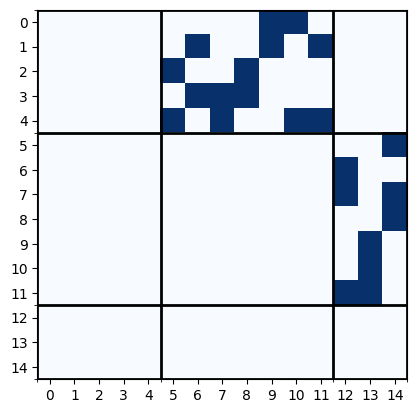

In [37]:
delta_matrix = np.zeros([16, 16], dtype=int)
delta_matrix[0, 1:6] = 1
delta_matrix[1:6, 6:13] = np.array([[1, 1, 0, 0, 0, 0, 0], 
                                    [1, 0, 1, 1, 0, 0, 0], 
                                    [0, 1, 1, 0, 1, 1, 0], 
                                    [0, 0, 0, 1, 1, 0, 1], 
                                    [0, 0, 0, 0, 0, 1, 1]])
delta_matrix[6:13, 13:16] = np.array([[1, 0, 0], 
                                      [1, 0, 0], 
                                      [1, 1, 0], 
                                      [0, 1, 0], 
                                      [0, 1, 1], 
                                      [0, 0, 1], 
                                      [0, 0, 1]])
reorder = np.array([ 0,  1,  2,  5,  4,  3, 11,  9, 10, 12,  6,  7,  8, 14, 13, 15])

ns = [1, 5, 7, 3]
delta_matrix = delta_matrix[reorder, :][:, reorder]

ns = ns[1:]
delta_matrix = delta_matrix[1:, 1:]

#ns = ns[:3]
#delta_matrix = delta_matrix[:13, :13]


show_boundary_matrix(delta_matrix, ns, set_lim=False)

In [38]:
df_transpositions = collect_transpositions(delta_matrix, ns, path='data/complexes/example')

print(f'df_transpositions.shape = {df_transpositions.shape}')
df_transpositions.head()

df_transpositions.shape = (11, 14)


,cell0,cell1,hash_bt,hash_at,dp_bt,dp_at,transposition,transposition_type,switch_type,nested,x,y,a,b
1,1,2,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,J2sqbpnQ48LtFe20HsEAUkqy4GGMjhte7HBokhi0RQA,<src.depth.DepthPoset object at 0x756211ea5f40>,<src.depth.DepthPoset object at 0x756211ea7110>,"<1, 2>",birth-birth,switch forward,True,2,7,1,9
2,2,3,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,Hch7Jy3ORtkQDDERc_N9PsJoEKcHTDKxRs83iZYppNk,<src.depth.DepthPoset object at 0x756211ea5f40>,<src.depth.DepthPoset object at 0x756211ea7cb0>,"<2, 3>",birth-birth,no switch,True,3,6,2,7
3,3,4,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,vzPUoxuvbCxEsI5SVC188-HNcPhtehVc4RNPBHsZLKg,<src.depth.DepthPoset object at 0x756211ea5f40>,<src.depth.DepthPoset object at 0x756211ea6b70>,"<3, 4>",birth-birth,no switch,False,4,5,3,6
4,5,6,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,a-wU4c_wAXKQ4SDVk2X3oDdjR0vNgXsB9DeLWDqQebQ,<src.depth.DepthPoset object at 0x756211ea5f40>,<src.depth.DepthPoset object at 0x756211ea5a60>,"<5, 6>",death-death,no switch,False,4,5,3,6
5,6,7,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,YYo5rnpYI2eOPTklPKOLf137xSx0ZEB1-KorpXOpnXw,<src.depth.DepthPoset object at 0x756211ea5f40>,<src.depth.DepthPoset object at 0x756211ea4380>,"<6, 7>",death-death,switch forward,True,3,6,2,7


In [39]:
df_transpositions_eqiations = check_equations(df_transpositions, with_preservation=True)

index_cols = ['transposition_type', 'switch_type', 'nested']
eq_cols = df_transpositions_eqiations.columns

df_transpositions_eqiations = pd.concat([df_transpositions, df_transpositions_eqiations], axis=1)


df_transpositions_eqiations.set_index(index_cols)[eq_cols].transpose().replace({True: '✔', False: '✘'}).fillna('').sort_index(axis=1)

transposition_type birth-birth                            birth-death  \
switch_type          no switch             switch forward   no switch   
nested                   False True  True           True        False   
Eq08                                                    ✔               
Eq09                                                    ✔               
Eq10                                                    ✔               
Eq11                                                    ✔               
Eq12                                                    ✔               
Eq13                                                    ✔               
Eq14                                                    ✔               
Eq15                                                    ✔               
Eq16                               ✔     ✔                              
Eq17                               ✔     ✔                              
Eq28                                                                    
Eq29                                                                    
Eq30                                                                    
Eq31                                                                    
Eq32                                                                    
Eq33                                                                    
Eq34                                                                    
Eq35                                                                    
Eq48                                                                    
Eq49                                                                    
Eq50                                                                    
Eq50a                                                                   
Eq50b                                                                   
Eq51                                                                    
Eq52                                                                    
Eq53                                                                    
Eq54                                                                    
Eq55                                                                    
Eq55a                                                                   
Eq55b                                                                   
EqPred1ab                    ✔                                      ✔   
EqPred1xy                    ✔                                      ✔   
EqPred2ab                    ✔                                      ✔   
EqPred2xy                    ✔                                      ✔   
EqSucc1ab                    ✔                                      ✔   
EqSucc1xy                    ✔                                      ✔   
EqSucc2ab                    ✔                                      ✔   
EqSucc2xy                    ✔                                      ✔   

transposition_type                      death-death                             
switch_type        switch forward         no switch       switch forward        
nested                      True  True        False False          True  True   
Eq08                                                                            
Eq09                                                                            
Eq10                                                                            
Eq11                                                                            
Eq12                                                                            
Eq13                                                                            
Eq14                                                                            
Eq15                                                                            
Eq16                                                                            
Eq17                              

In [40]:
path_complex = 'data/complexes/example'

filename_md = "reports/transpositions_stats-example.md"
filename_html = "reports/transpositions_stats-example.html"
os.makedirs('reports', exist_ok=True)

try:
    with open(filename_md, 'r') as file:
        text = file.read()
    print('Got markdown from file')
except FileNotFoundError:
    print('Generating markdown...')
    text = get_transpositions_stats(df_transpositions_eqiations, path=path_complex, imagewidth=1200)
    with open(filename_md, 'w') as file:
        file.write(text)

if not os.path.exists(filename_html):
    print('Generating html...')
    markdown_to_html(text, filename_html)

Generating markdown...


Wrong Transpositions: 100%|██████████| 2/2 [00:01<00:00,  1.69it/s]


Generating html...


# Abstract Random Complexes 

In [41]:
from src.abstract_complexes import get_random_boundary_matrix, get_boundary_matrix_ranks

In [42]:
np.random.seed(31)

In [43]:
df_cases = []

nss = [
    [6, 15, 18, 9]
]

for ns in nss:
    for bs in itertools.product(range(3), repeat=len(ns)):
        try:
            if bs[0] != 1:
                raise ValueError
            rs = get_boundary_matrix_ranks(ns, bs)
            df_cases.append({'ns': ns, 'bs': np.array(bs), 'rs': rs})
        except ValueError:
            pass

df_cases = pd.DataFrame(df_cases)
df_cases = df_cases[df_cases.apply(lambda row: np.all(row['ns'][1:] > row['rs']), axis=1)]

df_cases['repeat'] = 5

df_cases

,ns,bs,rs,repeat
0,"[6, 15, 18, 9]","[1, 0, 0, 1]","[5, 10, 8]",5
1,"[6, 15, 18, 9]","[1, 0, 1, 2]","[5, 10, 7]",5
3,"[6, 15, 18, 9]","[1, 1, 1, 1]","[5, 9, 8]",5
4,"[6, 15, 18, 9]","[1, 1, 2, 2]","[5, 9, 7]",5
6,"[6, 15, 18, 9]","[1, 2, 2, 1]","[5, 8, 8]",5


In [44]:
def case_generator(df_cases):
    for i_case, case in df_cases.iterrows():
        for repetition in range(case['repeat']):
            ns, bs = np.array(case['ns']), np.array(case['bs'])
            yield ns, bs
            

In [45]:
path_complex = 'data/complexes/abstract'
path_transps = 'data/transpositions/abstract'

os.makedirs(path_complex, exist_ok=True)
os.makedirs(path_transps, exist_ok=True)

filename_transps_template = os.path.join(path_transps, '{hash}.pkl')


dfs_transps = []

for ns, bs in tqdm(case_generator(df_cases), total=df_cases['repeat'].sum()):
    delta = get_random_boundary_matrix(ns, bs)
    data = get_delta_data(delta, ns, bs, path=path_complex)

    filename_transps = filename_transps_template.format(hash=data['hash'])

    try:
        with open(filename_transps, 'rb') as file:
            dfs_transps.append(pd.read_pickle(file))
    except FileNotFoundError:
        ns = pd.Series(data['dims']).value_counts().sort_index().values

        df_transps = collect_transpositions(delta, ns, betti=data['betti'], 
                                            path=path_complex, filter_unpaired=True)
        df_transps = pd.concat([df_transps, check_equations(df_transps, with_preservation=True)], axis=1)
        df_transps.to_pickle(filename_transps)
        dfs_transps.append(df_transps.copy())

df_transpositions = pd.concat(dfs_transps, axis=0)

print(f'df_transpositions.shape = {df_transpositions.shape}')
df_transpositions.head()

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:02<00:00, 11.77it/s]

df_transpositions.shape = (917, 59)


,cell0,cell1,hash_bt,hash_at,dp_bt,dp_at,transposition,transposition_type,switch_type,nested,...,Eq55a,Eq55b,EqPred1ab,EqPred1xy,EqPred2ab,EqPred2xy,EqSucc1ab,EqSucc1xy,EqSucc2ab,EqSucc2xy
2,2,3,amFTMHIVFMOJB9MtV6DsTajMdFwgqn5H0HNwXN_sdXI,odXkyApyv3wq7ji9h0vsGEP5oRX4dctM3glb1rxvKBA,<src.depth.DepthPoset object at 0x75620d7144a0>,<src.depth.DepthPoset object at 0x75620d72cc50>,"<2, 3>",birth-birth,no switch,True,...,None,None,None,None,None,None,None,None,None,None
3,3,4,amFTMHIVFMOJB9MtV6DsTajMdFwgqn5H0HNwXN_sdXI,o0csA7DBEvVT7hfZQP59oIQACW6lSWt0ZD3StQ1H1Pg,<src.depth.DepthPoset object at 0x75620d7144a0>,<src.depth.DepthPoset object at 0x75620d72f020>,"<3, 4>",birth-birth,switch backward,True,...,None,None,None,None,None,None,None,None,None,None
4,4,5,amFTMHIVFMOJB9MtV6DsTajMdFwgqn5H0HNwXN_sdXI,pc3NlPks-0TPcQb1bzuyM1_aCFdjcqqQbJfbc-iEdYI,<src.depth.DepthPoset object at 0x75620d7144a0>,<src.depth.DepthPoset object at 0x75620d6fba10>,"<4, 5>",birth-birth,no switch,True,...,None,None,None,None,None,None,None,None,None,None
5,6,7,amFTMHIVFMOJB9MtV6DsTajMdFwgqn5H0HNwXN_sdXI,aelvIegRcQMlrwf1basH3-TPh9ZZLplAs51MWqpmzG4,<src.depth.DepthPoset object at 0x75620d7144a0>,<src.depth.DepthPoset object at 0x75620d6f8680>,"<6, 7>",death-death,no switch,True,...,None,None,None,None,None,None,None,None,None,None
6,7,8,amFTMHIVFMOJB9MtV6DsTajMdFwgqn5H0HNwXN_sdXI,6z6RCW4cif756UbFFYCc4ivJjjh27QpzsO2y_LpItdA,<src.depth.DepthPoset object at 0x75620d7144a0>,<src.depth.DepthPoset object at 0x75620d6f99d0>,"<7, 8>",death-death,switch backward,True,...,None,None,None,None,None,None,None,None,None,None


In [46]:
eq_cols = df_transpositions.columns.values
eq_cols = eq_cols[list(map(lambda s: s.find('Eq') == 0, eq_cols))]
id_cols = ['transposition_type', 'switch_type', 'nested']

df_transpositions.groupby(id_cols)[eq_cols].mean().sort_index().transpose().map(lambda val: '' if pd.isna(val) else f'{100*val:.2f}%')

transposition_type birth-birth                                         \
switch_type          no switch         switch backward switch forward   
nested                   False   True            True           True    
Eq08                                                          100.00%   
Eq09                                                          100.00%   
Eq10                                                          100.00%   
Eq11                                                          100.00%   
Eq12                                                          100.00%   
Eq13                                                           45.45%   
Eq14                                                          100.00%   
Eq15                                                          100.00%   
Eq16                            48.00%                                  
Eq17                            48.00%                                  
Eq26                                           100.00%                  
Eq27                                           100.00%                  
Eq28                                                                    
Eq29                                                                    
Eq30                                                                    
Eq31                                                                    
Eq32                                                                    
Eq33                                                                    
Eq34                                                                    
Eq35                                                                    
Eq36                                                                    
Eq37                                                                    
Eq46                                                                    
Eq47                                                                    
Eq48                                                                    
Eq49                                                                    
Eq50                                                                    
Eq50a                                                                   
Eq50b                                                                   
Eq51                                                                    
Eq52                                                                    
Eq53                                                                    
Eq54                                                                    
Eq55                                                                    
Eq55a                                                                   
Eq55b                                                                   
EqPred1ab              100.00%                                          
EqPred1xy              100.00%                                          
EqPred2ab              100.00%                                          
EqPred2xy              100.00%                                          
EqSucc1ab              100.00%                                          
EqSucc1xy              100.00%                                          
EqSucc2ab              100.00%                                          
EqSucc2xy              100.00%                                          

transposition_type birth-death                death-death          \
switch_type          no switch switch forward   no switch           
nested                   False          True        False   True    
Eq08                                                                
Eq09                                                                
Eq10                                                                
Eq11                                                                
Eq12                                                                
Eq13            

In [47]:
((df_transpositions[eq_cols] == False).sum(axis=1) > 0).sum()

np.int64(239)

In [48]:
filename_md = "reports/transpositions_stats-abstract.md"
filename_html = "reports/transpositions_stats-abstract.html"

introduction_md = "texts/random-abstract-complex.md"
with open(introduction_md, 'r') as file:
    intro_text = file.read()


try:
    with open(filename_md, 'r') as file:
        text = file.read()
    print('Got markdown from file')
except FileNotFoundError:
    print('Generating markdown...')
    text = get_transpositions_stats(df_transpositions, path=path_complex, imagewidth=1200, intro_text=intro_text)
    with open(filename_md, 'w') as file:
        file.write(text)

if not os.path.exists(filename_html):
    print('Generating html...')
    markdown_to_html(text, filename_html)

Generating markdown...


Wrong Transpositions: 100%|██████████| 7/7 [00:04<00:00,  1.60it/s]


Generating html...
